# DTGS106. Simulating Different Image Modalities

<a href="https://colab.research.google.com/github/DeepTrackAI/DeepTrack2/blob/develop/tutorials/1-getting-started/DTGS106_particle_image_modalities.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg"></a>

In [ ]:
# !pip install deeptrack  # Uncomment if running on Colab/Kaggle.

This tutorial will demonstrate how to simulate a spherical particle with different image modalities and how to generate a movie where this particle diffuses with passive Brownian motion.

In [1]:
import deeptrack as dt
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


IMAGE_SIZE = 150  # Pixels

## 1. Fluorescence
Fluorescence images in `DeepTrack2` are simulated with discrete volumes that act as light sources emitting light.

Simulating fluorescence images is easy and straightforward to implement. 

Start by defining the particle ...

In [2]:
particle = dt.Sphere(
    position=(IMAGE_SIZE//2, IMAGE_SIZE//2, 2) * dt.units.pixel,
    radius= 0.3e-6,
    position_unit="pixel",
    intensity=1,
)

... define the microscope and image the particle.

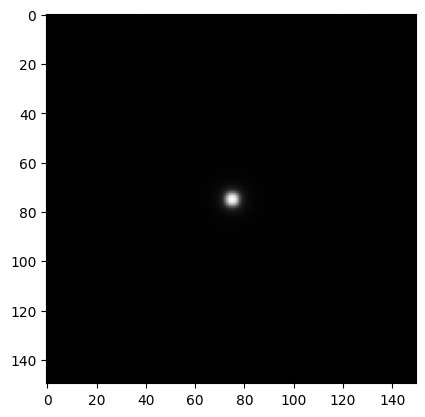

In [3]:
# Create a fluorescence microscope for a given wavelength.
fluorescence_optics = dt.Fluorescence(
    NA=1.4,
    resolution=1e-6,
    magnification=10,
    wavelength=600e-9,
    padding=(32, 32, 32, 32),
    output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
)

# Image the particle.
imaged_particle = fluorescence_optics(particle)

# Add background noise.
fluorescence_image_pipeline = (
    imaged_particle >> dt.Gaussian(0, 0.001)
)

fluorescence_image = fluorescence_image_pipeline.new()

plt.imshow(fluorescence_image, cmap="gray");

## 2. Brightfield

In `DeepTrack2`, the brightfield microscope simulates illumination using a single wavelength of light.

In experimental setups however, a brightfield microscope typically uses a broad spectrum of wavelengths (typically, white light).

To achieve a more realistic simulation of white light, you will need to simulate multiple brightfield images (sampling different parts of the visible light spectrum) and then average their contributions to the final image. 

You will start by generating a spectrum of wavelengths ...

In [4]:
# Generate a spectrum of wavelengths to sample from, 5 will be enough.
wavelengths = np.linspace(450e-9, 700e-9, 5)

... a particle scatterer object ...

In [5]:
particle = dt.Sphere(
    position=(IMAGE_SIZE//2, IMAGE_SIZE//2, 2) * dt.units.pixel,
    radius= 0.3e-6,
    position_unit="pixel",
    refractive_index=1.42,
)

... image the particle by sampling the spectrum.

/Users/cmanzo/Documents/GitHub/DeepTrack2/deeptrack/optical/optics.py:1878: UserWarning: Brightfield imaging from ScatteredVolume assumes a weak-phase / projection approximation. Use ScatteredField for physically accurate brightfield simulations.
  warnings.warn(


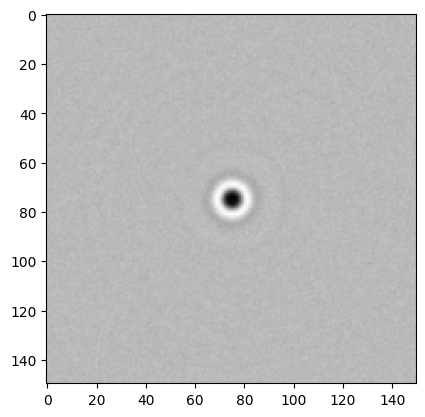

In [6]:
imaged_particle_list = []
for wavelength in wavelengths:

    # Create a brightfield microscope for a given wavelength.
    single_wavelength_optics = dt.Brightfield(
        resolution=1e-6,
        magnification=10,
        wavelength=wavelength,
        padding=(32, 32, 32, 32),
        output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
    )

    # Image the particle.
    imaged_particle = single_wavelength_optics(particle)

    # Add background noise.
    imaged_particle = imaged_particle >> dt.Gaussian(0, 0.01)

    # Append to list.
    imaged_particle_list.append(imaged_particle)

# Take the average of the images in the list.
brightfield_image_pipeline = (
    sum(imaged_particle_list) / len(imaged_particle_list)
)

brightfield_image = brightfield_image_pipeline.new()

plt.imshow(brightfield_image, cmap="gray");


## 3. Darkfield

Next, you will image a particle in a darkfield modality. This requires the scatterer to be defined as a Mie scatterer object.

In [7]:
mie_scatterer = dt.MieSphere(
    position=(IMAGE_SIZE//2, IMAGE_SIZE//2, 2) * dt.units.pixel,
    radius= 2e-6,
    position_unit="pixel",
    refractive_index=1.42,
    L=10,
)

Then, define the darkfield microscope ...

In [8]:
optics = dt.Darkfield(
    resolution=1e-6,
    magnification=10,
    wavelength=600e-9,
    padding=(32, 32, 32, 32),
    output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
)

... and image the particle through this.

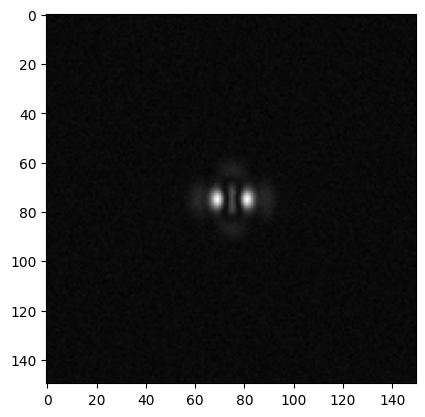

In [9]:
imaged_particle_list = []
for wavelength in wavelengths:

    # Create a darkfield microscope for a given wavelength.
    single_wavelength_optics = dt.Darkfield(
        resolution=1e-6,
        magnification=10,
        wavelength=wavelength,
        padding=(32, 32, 32, 32),
        output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
    )

    # Image the particle.
    imaged_particle = single_wavelength_optics(mie_scatterer)

    # Add background noise.
    imaged_particle = imaged_particle >> dt.Gaussian(0, 0.00015)

    # Append to list.
    imaged_particle_list.append(imaged_particle)

# Take the average of the images in the list.
darkfield_image_pipeline = (
    sum(imaged_particle_list) / len(imaged_particle_list)
)

darkfield_image = darkfield_image_pipeline.new()

plt.imshow(darkfield_image, cmap="gray");

## 4. Interferometric Scattering Microscopy (iSCAT)

-# TODO: Add text + check code below (also holography)

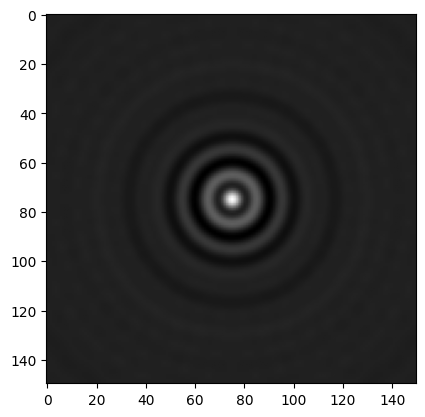

In [10]:
iscat_microscope = dt.ISCAT(
    resolution=1e-6,
    magnification=10,
    wavelength=600e-9,
    padding=(32, 32, 32, 32),
    output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
)

iscat_image_pipeline = iscat_microscope(mie_scatterer)

iscat_image = iscat_image_pipeline.new()

plt.imshow(iscat_image, cmap="gray");

## 5. Holographic Microscopy

A holographic microscope returns an image with real and imaginary values, so you will need to define a helper function that converts these into floats so you can visualize the values with a plot.

In [11]:
def complex_to_float_function_factory():
    """Converts a complex image to a float image, needed for Holography."""
    def inner(image):
        image = image - 1
        output = np.zeros((*image.shape[:2], 2))
        output[..., 0:1] = np.real(image)
        output[..., 1:2] = np.imag(image)
        return output
    return inner

complex_to_float = dt.Lambda(complex_to_float_function_factory)

Define the holography microscope and resolve a particle.

Image shape = (150, 150, 1)
Pixel value of (0, 0) = (1.0005598876004465+0.00012186476239673301j)


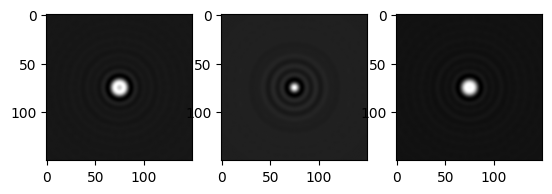

In [12]:
holography_microscope = dt.Holography(
    resolution=1e-6,
    magnification=10,
    wavelength=600e-9,
    padding=(32, 32, 32, 32),
    output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
    return_field=True,
)

# Get complex-valued image.
holography_image_pipeline = holography_microscope(mie_scatterer)

holography_image = holography_image_pipeline.new()
print(f"Image shape = {holography_image.shape}")

# Print a value in the image.
print(f"Pixel value of (0, 0) = {holography_image[0, 0, 0]}")

# Convert to floats.
converted_image = complex_to_float(holography_image)
holography_real = converted_image[:, :, 0]
holography_imag = converted_image[:, :, 1]
holography_combined = holography_real + holography_imag

fig, ax = plt.subplots(1, 3)
ax[0].imshow(holography_real, cmap="gray")
ax[1].imshow(holography_imag, cmap="gray")
ax[2].imshow(holography_combined, cmap="gray");



## 6. Simulating Passive Brownian Motion (Brightfield)

You can combine the optical tools together with equations of motion to simulate a realistic movie of a particle diffusing with Brownian motion.

In [13]:
MOVIE_LENGTH = 100
IMAGE_SIZE = 150
dx, dy, dz = IMAGE_SIZE//2, IMAGE_SIZE//2, 2

simulated_movie, x_positions, y_positions = [], [], []
for t in range(MOVIE_LENGTH):

    # Create a particle with a given position.
    particle = dt.Sphere(
        position=(dx, dy, dz) * dt.units.pixel,
        radius= 0.3e-6,
        refractive_index=1.42,
        position_unit="pixel",
        L=10,
    )

    # Sample wavelengths to obtain a good brightfield image.
    imaged_particle_list = []

    for wavelength in wavelengths:
        single_wavelength_optics = dt.Brightfield(
            resolution=1e-6,
            magnification=10,
            wavelength=wavelength,
            padding=(32, 32, 32, 32),
            output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
        )

        # Image particle.
        imaged_particle = single_wavelength_optics(particle)

        # Add noise.
        imaged_particle = imaged_particle >> dt.Gaussian(0, 0.01)

        # Append to list.
        imaged_particle_list.append(imaged_particle)

    # Average the images.
    image_pipeline = (sum(imaged_particle_list) / len(imaged_particle_list))
    image = image_pipeline.new()

    # Add images to list.
    simulated_movie.append(image)

    # Add positions to lists.
    x_positions.append(dx)
    y_positions.append(dy)

    # Update the displacements.
    dx += np.random.standard_normal() * 2.0
    dy += np.random.standard_normal() * 2.0
    dz += np.random.standard_normal() * 2.0

### Plotting the Trajectory

With the particles position recorded over time, you can plot the resulting trajectory and overlap it with the final image in the movie.

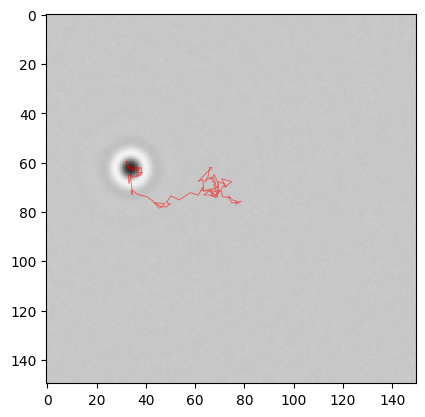

In [14]:
# Get dynamic range across all frames.
vmin = np.min(simulated_movie)
vmax = np.max(simulated_movie)

plt.imshow(simulated_movie[-1], cmap="gray", vmin=vmin, vmax=vmax)
plt.plot(y_positions, x_positions, c="r", linewidth=0.7, alpha=0.5);

### Making an Animation

Using `FuncAnimation` and a `HTML` player, you can combine the simulated frames into a movie.

In [15]:
# Create figure to display frames.
fig, ax = plt.subplots(figsize=(8, 8))

im = ax.imshow(simulated_movie[0], cmap="gray", vmin=vmin, vmax=vmax)
ax.set_axis_off()
ax.set_title("Passive Brownian Motion with Brightfield")

# Function to update the figure for a given frame.
def update(frame):
    im.set_data(simulated_movie[frame])
    return [im]

# Make animation.
animation = FuncAnimation(fig, update, frames=len(simulated_movie))

# Animation player as a HTML object.
player = HTML(animation.to_jshtml(fps=10));
plt.close()

# Call player to view the movie. 
player